In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import transforms

from PIL import Image

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
12.8
True
Tesla T4


In [2]:
train = pd.read_csv('/content/fashion-mnist_train.csv')
test = pd.read_csv('/content/fashion-mnist_test.csv')

In [3]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103.0,87.0,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,0,0,0,0,0,0,0,0,...,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0,0,0,0,0,0,14,53,99,...,0.0,0.0,0.0,0.0,63.0,53.0,31.0,0.0,0.0,0.0
3,2,0,0,0,0,0,0,0,0,0,...,137.0,126.0,140.0,0.0,133.0,224.0,222.0,56.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [6]:
custom_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
class CustomDataset(Dataset):
  def __init__(self, X, y, transform):
      self.X = X.reshape(-1, 1, 28, 28)
      self.y = y
      self.transform = transform

  def __len__(self):
      return len(self.X)

  def __getitem__(self, index):
      image = self.X[index].reshape(28, 28)
      image = image.astype(np.uint8)
      image = np.stack([image] * 3, axis=-1)
      image = Image.fromarray(image)
      image = self.transform(image)

      return image, torch.tensor(self.y[index], dtype=torch.long)

In [8]:
train_dataset = CustomDataset(X_train, y_train, transform=custom_transforms)
val_dataset = CustomDataset(X_val, y_val, transform=custom_transforms)
test_dataset = CustomDataset(X_test, y_test, transform=custom_transforms)

In [9]:
best_loss = float('inf')
patience = 10
counter = 0

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []

In [10]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

epochs = 50

loss_function = nn.CrossEntropyLoss()

In [11]:
import torchvision.models as models

vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 162MB/s]


In [12]:
for param in vgg16.parameters():
    param.requires_grad=False

In [13]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(512, 10),
)

In [14]:
vgg16 = vgg16.to(device)

In [15]:
optimizer = optim.Adam(
    vgg16.classifier.parameters(),
    lr=1e-3,
)

In [16]:
for epoch in range(epochs):

    vgg16.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.float().to(device)
        y_batch = y_batch.to(device)

        y_pred = vgg16(X_batch)

        prediction = torch.argmax(
            y_pred,
            dim=1
        )

        train_correct += (y_batch == prediction).sum().item()

        train_total += y_batch.size(0)

        loss = loss_function(y_pred, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()


    vgg16.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.float().to(device)
            y_batch = y_batch.to(device)

            y_pred = vgg16(X_batch)
            predictions = torch.argmax(
                y_pred,
                dim=1
            )

            val_correct += (
                predictions == y_batch
            ).sum().item()

            val_total += y_batch.size(0)
            loss = loss_function(y_pred, y_batch)

            val_loss += loss.item()


    train_loss = train_loss / len(train_loader)
    train_accuracy  = (train_correct / train_total)

    val_loss = val_loss / len(val_loader)
    val_accuracy = (val_correct / val_total)

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    train_acc_history.append(
        train_accuracy
    )

    val_acc_history.append(
        val_accuracy
    )

    print(
        f'Epoch {epoch+1} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Train Acc: {train_accuracy:.4f} | '
        f'Val Acc: {val_accuracy:.4f}'
    )

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0

        torch.save(
            vgg16.state_dict(),
            'best_model.pth'
        )
    else:
        counter += 1

        if counter >= patience:
            print("\nEarly Stopping")
            break

/tmp/ipykernel_2876/4030850031.py:12: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


Epoch 1 | Train Loss: 0.6380 | Val Loss: 0.3453 | Train Acc: 0.7791 | Val Acc: 0.8760
Epoch 2 | Train Loss: 0.2394 | Val Loss: 0.3081 | Train Acc: 0.9264 | Val Acc: 0.8839
Epoch 3 | Train Loss: 0.1012 | Val Loss: 0.2974 | Train Acc: 0.9726 | Val Acc: 0.8971
Epoch 4 | Train Loss: 0.0375 | Val Loss: 0.3417 | Train Acc: 0.9927 | Val Acc: 0.8918
Epoch 5 | Train Loss: 0.0195 | Val Loss: 0.3493 | Train Acc: 0.9964 | Val Acc: 0.8905
Epoch 6 | Train Loss: 0.0110 | Val Loss: 0.3568 | Train Acc: 0.9983 | Val Acc: 0.8984
Epoch 7 | Train Loss: 0.0073 | Val Loss: 0.3751 | Train Acc: 0.9990 | Val Acc: 0.8931
Epoch 8 | Train Loss: 0.0070 | Val Loss: 0.3901 | Train Acc: 0.9990 | Val Acc: 0.8971
Epoch 9 | Train Loss: 0.0045 | Val Loss: 0.4089 | Train Acc: 0.9997 | Val Acc: 0.8984
Epoch 10 | Train Loss: 0.0034 | Val Loss: 0.4107 | Train Acc: 0.9997 | Val Acc: 0.8945
Epoch 11 | Train Loss: 0.0029 | Val Loss: 0.4000 | Train Acc: 0.9997 | Val Acc: 0.8997
Epoch 12 | Train Loss: 0.0023 | Val Loss: 0.4122 | T

In [17]:
vgg16.eval()

correct = 0
total = 0

vgg16.load_state_dict(
    torch.load(
        'best_model.pth'
    )
)

with torch.no_grad():
  for X_batch, y_batch in test_loader:

    X_batch = X_batch.float().to(device)
    y_batch = y_batch.to(device)

    y_pred = vgg16(X_batch)

    predictions = torch.argmax( y_pred, dim=1 )

    correct += ( predictions == y_batch ).sum().item()

    total += y_batch.size(0)

accuracy = ( correct / total )
print( f'\nAccuracy: {accuracy*100:.2f}%')


Accuracy: 88.92%


/tmp/ipykernel_2876/4030850031.py:12: RuntimeWarning: invalid value encountered in cast
  image = image.astype(np.uint8)


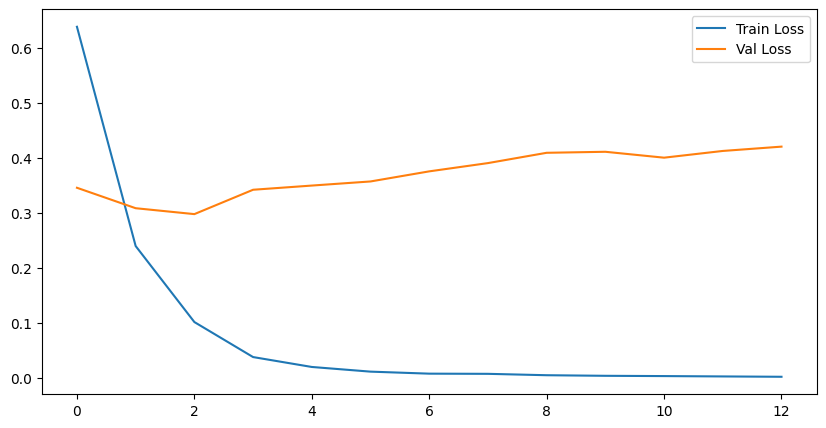

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    train_loss_history,
    label='Train Loss'
)

plt.plot(
    val_loss_history,
    label='Val Loss'
)

plt.legend()

plt.show()

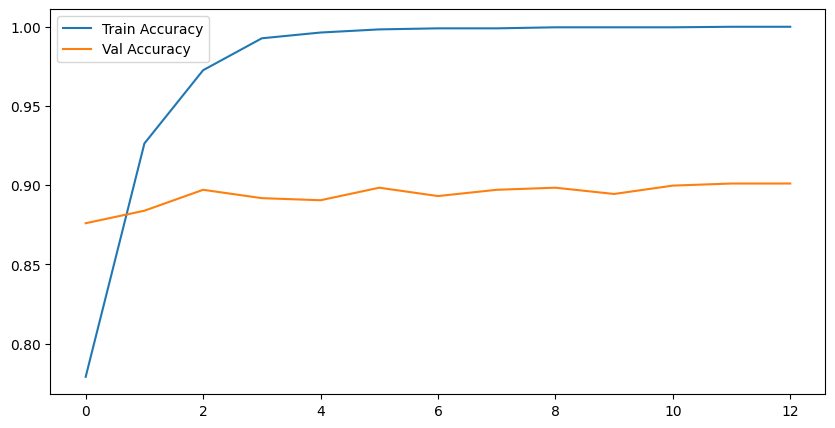

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    train_acc_history,
    label='Train Accuracy'
)

plt.plot(
    val_acc_history,
    label='Val Accuracy'
)

plt.legend()

plt.show()